# Laboratorio 8 - Maquinas Vectoriales de Soporte (SVM)
### CC3074 - Mineria de Datos | Universidad del Valle de Guatemala
### SmartStay Advisors

## Librerias

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import pyreadr

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn import metrics, set_config
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.style.use('ggplot')

## Actividad 1. Uso de los mismos conjuntos de entrenamiento y prueba de hojas anteriores

In [ ]:
result = pyreadr.read_r('data/listings.RData')
df = result[list(result.keys())[0]]
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [ ]:
# Limpieza de precio (igual que hojas anteriores)
if df['price'].dtype == object:
    df['price'] = df['price'].astype(str).str.replace(r'[$,]', '', regex=True).str.strip()
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
else:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna(subset=['price'])
df = df[df['price'] > 0]
df = df[df['price'] <= 1000]  # filtro de outliers aplicado en labs anteriores

print(f"Filas despues de limpieza: {len(df)}")
print(f"Precio min: ${df['price'].min():.2f} | max: ${df['price'].max():.2f} | promedio: ${df['price'].mean():.2f}")

Filas despues de limpieza: 72284
Precio min: $8.00 | max: $1000.00 | promedio: $237.92


## Actividad 2. Exploracion de datos y transformaciones para SVM

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72284 entries, 0 to 164212
Data columns (total 80 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            72284 non-null  float64
 1   listing_url                                   72284 non-null  object 
 2   scrape_id                                     72284 non-null  float64
 3   last_scraped                                  72284 non-null  object 
 4   source                                        72284 non-null  object 
 5   name                                          72284 non-null  object 
 6   description                                   72284 non-null  object 
 7   neighborhood_overview                         72284 non-null  object 
 8   picture_url                                   72284 non-null  object 
 9   host_id                                       72284 non-null  int

In [ ]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0].sort_values(ascending=False))

Valores nulos por columna:
calendar_updated                72284
neighbourhood_group_cleansed    37143
review_scores_rating            11554
review_scores_value             11554
review_scores_location          11554
review_scores_communication     11554
review_scores_checkin           11554
review_scores_cleanliness       11554
review_scores_accuracy          11554
reviews_per_month               11554
license                         10212
host_total_listings_count         627
host_listings_count               627
bedrooms                          106
beds                               72
maximum_maximum_nights             47
minimum_maximum_nights             47
maximum_minimum_nights             47
minimum_minimum_nights             47
bathrooms                          12
dtype: int64


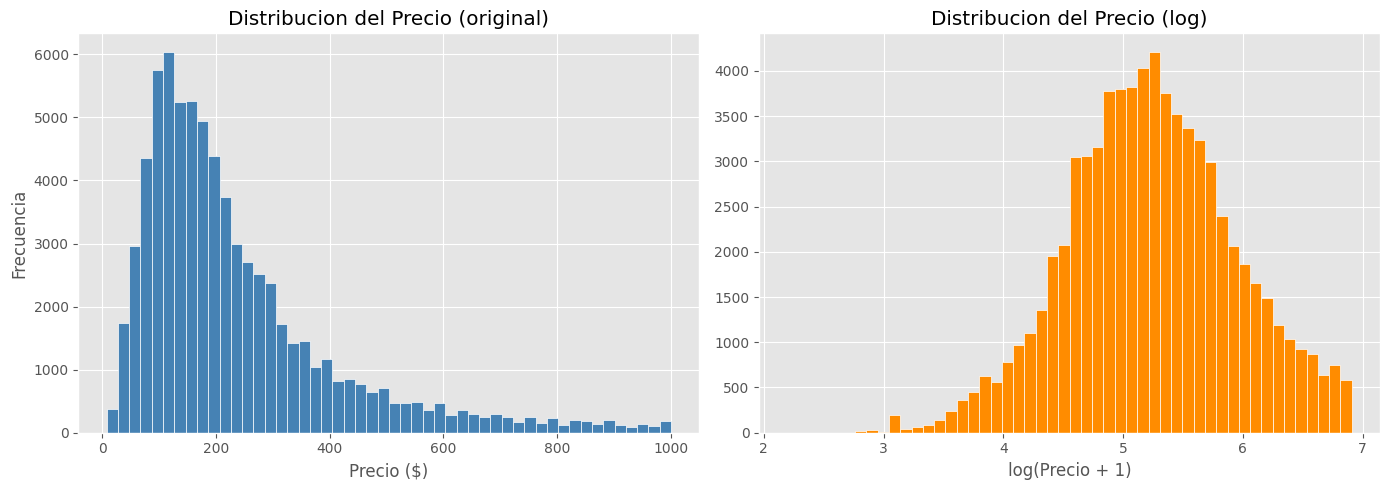

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion del Precio (original)')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['price']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribucion del Precio (log)')
axes[1].set_xlabel('log(Precio + 1)')
plt.tight_layout()
plt.show()

In [ ]:
# Seleccion de variables (mismas usadas en labs anteriores)
columnas_numericas = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'number_of_reviews', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'calculated_host_listings_count', 'availability_365'
]
columnas_categoricas = ['neighbourhood_cleansed', 'property_type', 'room_type']

columnas_numericas   = [c for c in columnas_numericas   if c in df.columns]
columnas_categoricas = [c for c in columnas_categoricas if c in df.columns]

print("Variables numericas:",   columnas_numericas)
print("\nVariables categoricas:", columnas_categoricas)
print("""
Transformaciones necesarias para SVM:
  - Normalizacion con StandardScaler (SVM es sensible a la escala).
  - Imputacion de nulos: mediana para numericas, moda para categoricas.
  - Codificacion OneHot para variables categoricas.
  - Uso de submuestra para kernels no lineales (complejidad O(n^2)).
""")

Variables numericas: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'availability_365']

Variables categoricas: ['neighbourhood_cleansed', 'property_type', 'room_type']

Transformaciones necesarias para SVM:
  - Normalizacion con StandardScaler (SVM es sensible a la escala).
  - Imputacion de nulos: mediana para numericas, moda para categoricas.
  - Codificacion OneHot para variables categoricas.
  - Uso de submuestra para kernels no lineales (complejidad O(n^2)).



In [ ]:
# Pipeline de preprocesamiento
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocesador = ColumnTransformer([
    ('numerico',   numeric_preprocessor,     columnas_numericas),
    ('categorico', categorical_preprocessor, columnas_categoricas)
], remainder='drop')

print("Preprocesador configurado.")

Preprocesador configurado.


## Actividad 3. Variable respuesta categorica de precio

In [ ]:
# Percentiles 33 y 66, consistente con labs anteriores
p33 = df['price'].quantile(0.33)
p66 = df['price'].quantile(0.66)
print(f"Percentil 33: ${p33:.2f}  |  Percentil 66: ${p66:.2f}")

def categorizar_precio(precio):
    if precio <= p33:
        return 'Economica'
    elif precio <= p66:
        return 'Intermedia'
    else:
        return 'Cara'

df['price_category'] = df['price'].apply(categorizar_precio)
print("\nDistribucion de categorias:")
print(df['price_category'].value_counts())

Percentil 33: $136.00  |  Percentil 66: $246.00

Distribucion de categorias:
price_category
Cara          24503
Intermedia    23903
Economica     23878
Name: count, dtype: int64


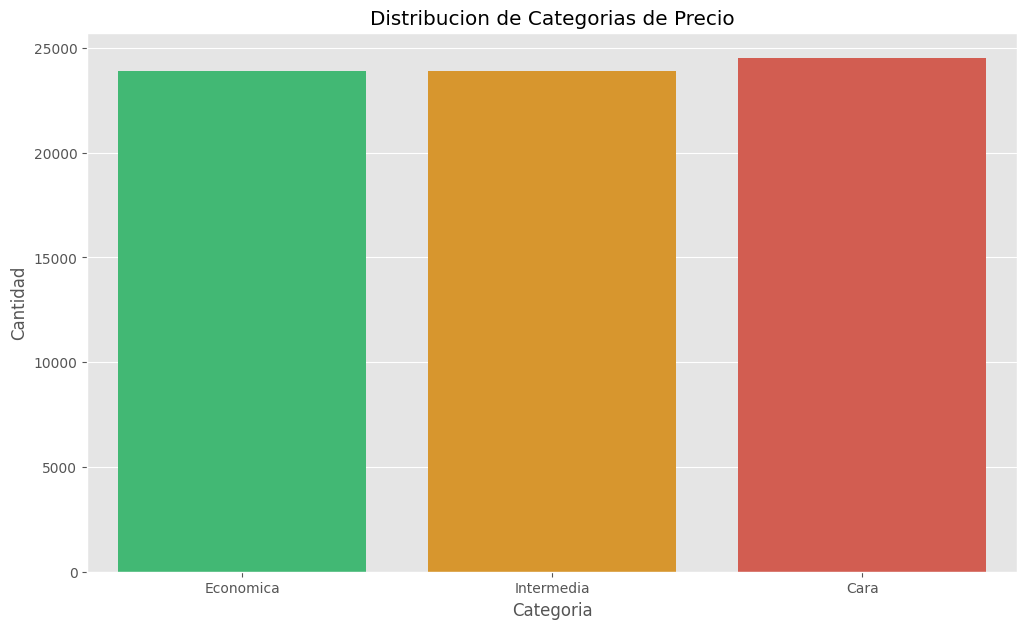

In [ ]:
cat_counts = df['price_category'].value_counts().reset_index()
cat_counts.columns = ['Categoria', 'Cantidad']
sb.barplot(x='Categoria', y='Cantidad', data=cat_counts,
           palette=['#2ecc71', '#f39c12', '#e74c3c'],
           order=['Economica', 'Intermedia', 'Cara'])
plt.title('Distribucion de Categorias de Precio')
plt.show()

In [ ]:
# Division de datos: 80/20 con random_state=42 (mismos que labs anteriores)
todas_variables = columnas_numericas + columnas_categoricas
X       = df[todas_variables].copy()
y_class = df['price_category'].copy()
y_reg   = df['price'].copy()

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.20, random_state=42, stratify=y_class
)
y_train_reg = y_reg.loc[X_train.index]
y_test_reg  = y_reg.loc[X_test.index]

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 57827 filas (80%)
Test:  14457 filas (20%)


In [ ]:
# Submuestra para kernels no lineales (SVC es O(n^2))
MAX_TRAIN_SVC = 5000

if len(X_train) > MAX_TRAIN_SVC:
    X_train_svc, _, y_train_svc, _ = train_test_split(
        X_train, y_train_class,
        train_size=MAX_TRAIN_SVC,
        random_state=42,
        stratify=y_train_class
    )
    print(f"Submuestra para kernels no lineales: {X_train_svc.shape[0]} filas")
else:
    X_train_svc = X_train
    y_train_svc = y_train_class

Submuestra para kernels no lineales: 5000 filas


## Funcion de evaluacion

In [ ]:
CLASES = ['Economica', 'Intermedia', 'Cara']
resultados_clasificacion = []

def evaluar_clasificacion(modelo, X_tr, y_tr, X_te, y_te, nombre):
    inicio = time.time()
    modelo.fit(X_tr, y_tr)
    tiempo = time.time() - inicio

    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    acc_tr  = metrics.accuracy_score(y_tr, y_pred_tr)
    acc_te  = metrics.accuracy_score(y_te, y_pred_te)
    prec    = metrics.precision_score(y_te, y_pred_te, average='weighted', zero_division=0)
    rec     = metrics.recall_score(y_te,    y_pred_te, average='weighted', zero_division=0)
    f1      = metrics.f1_score(y_te,         y_pred_te, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f" {nombre}")
    print(f"{'='*55}")
    print(f" Accuracy Train : {acc_tr:.4f}")
    print(f" Accuracy Test  : {acc_te:.4f}")
    print(f" Diferencia     : {acc_tr - acc_te:.4f}")
    print(f" Precision      : {prec:.4f}")
    print(f" Recall         : {rec:.4f}")
    print(f" F1-Score       : {f1:.4f}")
    print(f" Tiempo (s)     : {tiempo:.2f}")
    print(f" Sobreajuste    : {'Si' if acc_tr - acc_te > 0.05 else 'No'}")
    print("\nReporte de Clasificacion:")
    print(classification_report(y_te, y_pred_te, target_names=CLASES, zero_division=0))

    cm = confusion_matrix(y_te, y_pred_te, labels=CLASES)
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
    plt.tight_layout()
    plt.show()

    return {
        'Modelo':      nombre,
        'Acc_Train':   round(acc_tr, 4),
        'Acc_Test':    round(acc_te, 4),
        'Diferencia':  round(acc_tr - acc_te, 4),
        'F1':          round(f1,  4),
        'Precision':   round(prec, 4),
        'Recall':      round(rec, 4),
        'Tiempo_s':    round(tiempo, 2),
        'Sobreajuste': 'Si' if acc_tr - acc_te > 0.05 else 'No'
    }

## Actividad 4. Modelos SVM con distintos kernels y parametros

### Modelo 1 - Kernel Lineal (LinearSVC)

In [ ]:
set_config(display='diagram')
modelo_lineal = make_pipeline(
    preprocesador,
    LinearSVC(C=1.0, max_iter=3000, random_state=42, dual='auto')
)
modelo_lineal

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerico', ...), ('categorico', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff


 SVM - Kernel Lineal / LinearSVC (C=1)
 Accuracy Train : 0.6791
 Accuracy Test  : 0.6669
 Diferencia     : 0.0123
 Precision      : 0.6547
 Recall         : 0.6669
 F1-Score       : 0.6547
 Tiempo (s)     : 9.62
 Sobreajuste    : No

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.68      0.79      0.73      4901
  Intermedia       0.72      0.80      0.76      4775
        Cara       0.56      0.41      0.47      4781

    accuracy                           0.67     14457
   macro avg       0.65      0.67      0.65     14457
weighted avg       0.65      0.67      0.65     14457



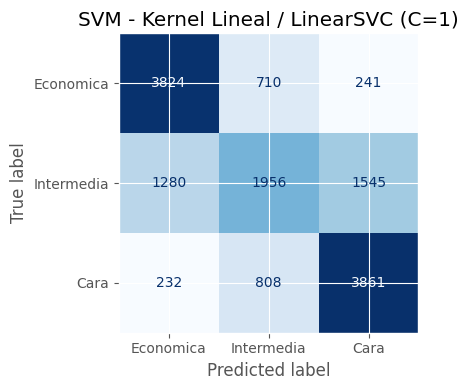

In [ ]:
# LinearSVC usa el conjunto completo de entrenamiento
res = evaluar_clasificacion(
    modelo_lineal, X_train, y_train_class, X_test, y_test_class,
    'SVM - Kernel Lineal / LinearSVC (C=1)'
)
resultados_clasificacion.append(res)

### Modelo 2 - Kernel Lineal con C=10


 SVM - Kernel Lineal / LinearSVC (C=10)
 Accuracy Train : 0.6794
 Accuracy Test  : 0.6672
 Diferencia     : 0.0122
 Precision      : 0.6550
 Recall         : 0.6672
 F1-Score       : 0.6551
 Tiempo (s)     : 12.21
 Sobreajuste    : No

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.68      0.79      0.73      4901
  Intermedia       0.72      0.80      0.76      4775
        Cara       0.56      0.41      0.47      4781

    accuracy                           0.67     14457
   macro avg       0.65      0.67      0.65     14457
weighted avg       0.66      0.67      0.66     14457



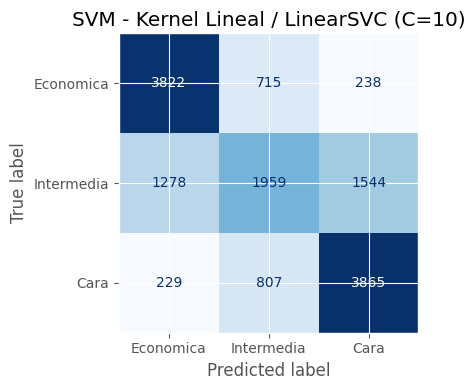

In [ ]:
modelo_lineal_c10 = make_pipeline(
    preprocesador,
    LinearSVC(C=10.0, max_iter=3000, random_state=42, dual='auto')
)
res = evaluar_clasificacion(
    modelo_lineal_c10, X_train, y_train_class, X_test, y_test_class,
    'SVM - Kernel Lineal / LinearSVC (C=10)'
)
resultados_clasificacion.append(res)

### Modelo 3 - Kernel Polinomial (C=5, d=3)


 SVM - Kernel Polinomial (C=5, d=3)
 Accuracy Train : 0.7908
 Accuracy Test  : 0.6469
 Diferencia     : 0.1439
 Precision      : 0.6604
 Recall         : 0.6469
 F1-Score       : 0.6512
 Tiempo (s)     : 6.21
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.73      0.66      0.69      4901
  Intermedia       0.74      0.67      0.70      4775
        Cara       0.51      0.61      0.56      4781

    accuracy                           0.65     14457
   macro avg       0.66      0.65      0.65     14457
weighted avg       0.66      0.65      0.65     14457



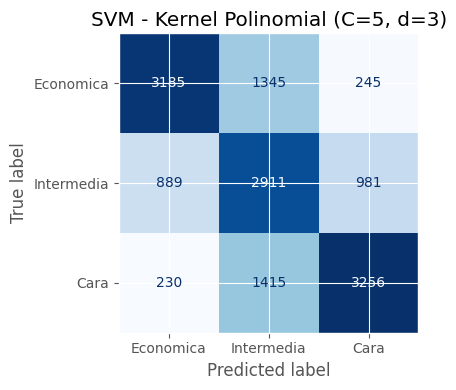

In [ ]:
# Se usa submuestra para kernels no lineales
modelo_poly = make_pipeline(
    preprocesador,
    SVC(kernel='poly', C=5.0, degree=3, gamma='scale', cache_size=500, random_state=42)
)
res = evaluar_clasificacion(
    modelo_poly, X_train_svc, y_train_svc, X_test, y_test_class,
    'SVM - Kernel Polinomial (C=5, d=3)'
)
resultados_clasificacion.append(res)

### Modelo 4 - Kernel Polinomial (C=16, d=5)


 SVM - Kernel Polinomial (C=16, d=5)
 Accuracy Train : 0.7980
 Accuracy Test  : 0.5921
 Diferencia     : 0.2059
 Precision      : 0.6451
 Recall         : 0.5921
 F1-Score       : 0.5986
 Tiempo (s)     : 6.01
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.74      0.52      0.61      4901
  Intermedia       0.74      0.56      0.64      4775
        Cara       0.45      0.70      0.55      4781

    accuracy                           0.59     14457
   macro avg       0.64      0.59      0.60     14457
weighted avg       0.65      0.59      0.60     14457



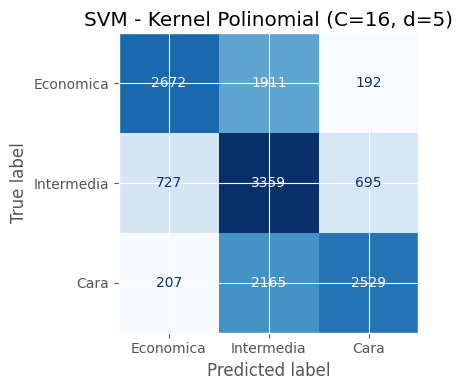

In [ ]:
modelo_poly2 = make_pipeline(
    preprocesador,
    SVC(kernel='poly', C=16.0, degree=5, gamma='scale', cache_size=500, random_state=42)
)
res = evaluar_clasificacion(
    modelo_poly2, X_train_svc, y_train_svc, X_test, y_test_class,
    'SVM - Kernel Polinomial (C=16, d=5)'
)
resultados_clasificacion.append(res)

### Modelo 5 - Kernel RBF (C=10, gamma=0.01)


 SVM - Kernel RBF (C=10, gamma=0.01)
 Accuracy Train : 0.7374
 Accuracy Test  : 0.6727
 Diferencia     : 0.0647
 Precision      : 0.6758
 Recall         : 0.6727
 F1-Score       : 0.6740
 Tiempo (s)     : 6.05
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.73      0.71      0.72      4901
  Intermedia       0.75      0.74      0.74      4775
        Cara       0.55      0.57      0.56      4781

    accuracy                           0.67     14457
   macro avg       0.68      0.67      0.67     14457
weighted avg       0.68      0.67      0.67     14457



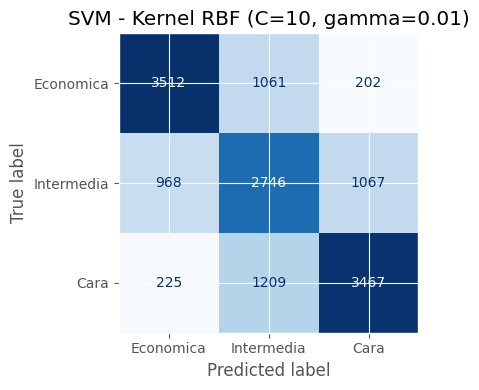

In [ ]:
modelo_rbf = make_pipeline(
    preprocesador,
    SVC(kernel='rbf', C=10.0, gamma=0.01, cache_size=500, random_state=42)
)
res = evaluar_clasificacion(
    modelo_rbf, X_train_svc, y_train_svc, X_test, y_test_class,
    'SVM - Kernel RBF (C=10, gamma=0.01)'
)
resultados_clasificacion.append(res)

### Modelo 6 - Kernel RBF (C=50, gamma=scale)


 SVM - Kernel RBF (C=50, gamma=scale)
 Accuracy Train : 0.9588
 Accuracy Test  : 0.6398
 Diferencia     : 0.3190
 Precision      : 0.6409
 Recall         : 0.6398
 F1-Score       : 0.6399
 Tiempo (s)     : 6.65
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.67      0.71      0.69      4901
  Intermedia       0.73      0.68      0.71      4775
        Cara       0.52      0.52      0.52      4781

    accuracy                           0.64     14457
   macro avg       0.64      0.64      0.64     14457
weighted avg       0.64      0.64      0.64     14457



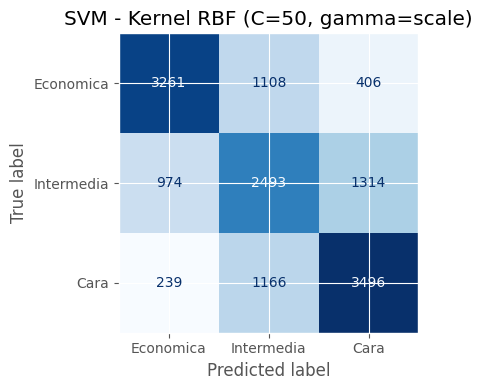

In [ ]:
modelo_rbf2 = make_pipeline(
    preprocesador,
    SVC(kernel='rbf', C=50.0, gamma='scale', cache_size=500, random_state=42)
)
res = evaluar_clasificacion(
    modelo_rbf2, X_train_svc, y_train_svc, X_test, y_test_class,
    'SVM - Kernel RBF (C=50, gamma=scale)'
)
resultados_clasificacion.append(res)

### Modelo 7 - Kernel Sigmoide


 SVM - Kernel Sigmoide (C=1)
 Accuracy Train : 0.5122
 Accuracy Test  : 0.5032
 Diferencia     : 0.0090
 Precision      : 0.5010
 Recall         : 0.5032
 F1-Score       : 0.5005
 Tiempo (s)     : 2.65
 Sobreajuste    : No

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.54      0.63      0.58      4901
  Intermedia       0.60      0.54      0.57      4775
        Cara       0.37      0.34      0.35      4781

    accuracy                           0.50     14457
   macro avg       0.50      0.50      0.50     14457
weighted avg       0.50      0.50      0.50     14457



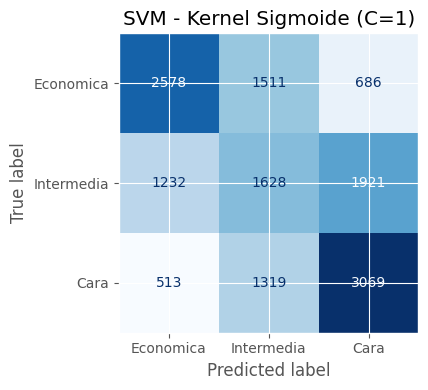

In [ ]:
modelo_sigmoid = make_pipeline(
    preprocesador,
    SVC(kernel='sigmoid', C=1.0, gamma='scale', cache_size=500, random_state=42)
)
res = evaluar_clasificacion(
    modelo_sigmoid, X_train_svc, y_train_svc, X_test, y_test_class,
    'SVM - Kernel Sigmoide (C=1)'
)
resultados_clasificacion.append(res)

### Tuneo automatico con GridSearchCV

In [ ]:
print("Tuneando kernel RBF...")
modelo_rbf_gs = make_pipeline(
    preprocesador,
    SVC(kernel='rbf', cache_size=500, random_state=42)
)
param_grid_rbf = {
    'svc__C':     [0.1, 1, 10, 50],
    'svc__gamma': [0.001, 0.01, 0.1, 'scale']
}
grid_rbf = GridSearchCV(modelo_rbf_gs, param_grid_rbf, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid_rbf.fit(X_train_svc, y_train_svc)

print(f"\nMejores parametros RBF : {grid_rbf.best_params_}")
print(f"Accuracy CV            : {grid_rbf.best_score_:.4f}")
print(f"Accuracy Test          : {grid_rbf.score(X_test, y_test_class):.4f}")

Tuneando kernel RBF...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores parametros RBF : {'svc__C': 50, 'svc__gamma': 0.01}
Accuracy CV            : 0.6666
Accuracy Test          : 0.6790


In [ ]:
cv_results_rbf = pd.DataFrame(grid_rbf.cv_results_).sort_values('mean_test_score', ascending=False)
print("Top 5 combinaciones RBF:")
cv_results_rbf[['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'std_test_score']].head()

Top 5 combinaciones RBF:


,param_svc__C,param_svc__gamma,mean_test_score,std_test_score
13,50.0,0.01,0.6666,0.013215
9,10.0,0.01,0.6620,0.009550
12,50.0,0.001,0.6616,0.016032
11,10.0,scale,0.6608,0.017371
7,1.0,scale,0.6442,0.019156


In [ ]:
print("Tuneando kernel Polinomial...")
modelo_poly_gs = make_pipeline(
    preprocesador,
    SVC(kernel='poly', cache_size=500, random_state=42)
)
param_grid_poly = {
    'svc__C':      [0.1, 1, 5, 16],
    'svc__degree': [2, 3, 5]
}
grid_poly = GridSearchCV(modelo_poly_gs, param_grid_poly, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid_poly.fit(X_train_svc, y_train_svc)

print(f"\nMejores parametros Polinomial : {grid_poly.best_params_}")
print(f"Accuracy CV                   : {grid_poly.best_score_:.4f}")
print(f"Accuracy Test                 : {grid_poly.score(X_test, y_test_class):.4f}")

Tuneando kernel Polinomial...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parametros Polinomial : {'svc__C': 16, 'svc__degree': 2}
Accuracy CV                   : 0.6534
Accuracy Test                 : 0.6631



 SVM-RBF Tuneado {'svc__C': 50, 'svc__gamma': 0.01}
 Accuracy Train : 0.8008
 Accuracy Test  : 0.6790
 Diferencia     : 0.1218
 Precision      : 0.6819
 Recall         : 0.6790
 F1-Score       : 0.6802
 Tiempo (s)     : 4.74
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.72      0.74      0.73      4901
  Intermedia       0.76      0.72      0.74      4775
        Cara       0.56      0.58      0.57      4781

    accuracy                           0.68     14457
   macro avg       0.68      0.68      0.68     14457
weighted avg       0.68      0.68      0.68     14457



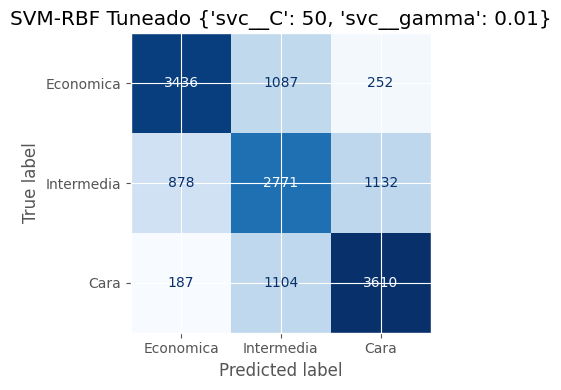

In [ ]:
res_rbf_tuned = evaluar_clasificacion(
    grid_rbf.best_estimator_, X_train_svc, y_train_svc, X_test, y_test_class,
    f"SVM-RBF Tuneado {grid_rbf.best_params_}"
)
resultados_clasificacion.append(res_rbf_tuned)


 SVM-Polinomial Tuneado {'svc__C': 16, 'svc__degree': 2}
 Accuracy Train : 0.8348
 Accuracy Test  : 0.6631
 Diferencia     : 0.1717
 Precision      : 0.6680
 Recall         : 0.6631
 F1-Score       : 0.6650
 Tiempo (s)     : 4.53
 Sobreajuste    : Si

Reporte de Clasificacion:
              precision    recall  f1-score   support

   Economica       0.71      0.71      0.71      4901
  Intermedia       0.76      0.70      0.73      4775
        Cara       0.54      0.58      0.56      4781

    accuracy                           0.66     14457
   macro avg       0.67      0.66      0.66     14457
weighted avg       0.67      0.66      0.66     14457



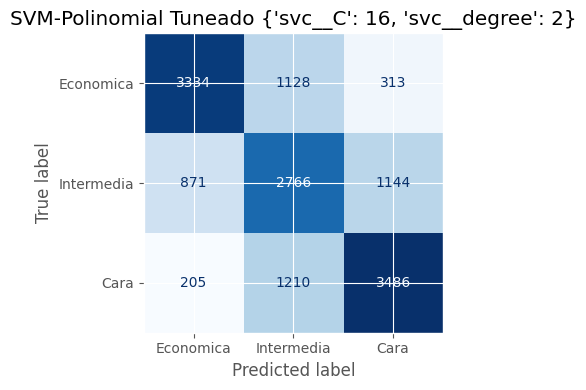

In [ ]:
res_poly_tuned = evaluar_clasificacion(
    grid_poly.best_estimator_, X_train_svc, y_train_svc, X_test, y_test_class,
    f"SVM-Polinomial Tuneado {grid_poly.best_params_}"
)
resultados_clasificacion.append(res_poly_tuned)

## Actividad 5. Prediccion con los modelos SVM


In [ ]:
df_svm = pd.DataFrame(resultados_clasificacion)
print("Resumen de predicciones por modelo SVM:")
print(df_svm[['Modelo', 'Acc_Train', 'Acc_Test', 'F1', 'Tiempo_s']].to_string(index=False))

Resumen de predicciones por modelo SVM:
                                                 Modelo  Acc_Train  Acc_Test     F1  Tiempo_s
                  SVM - Kernel Lineal / LinearSVC (C=1)     0.6791    0.6669 0.6547      9.62
                 SVM - Kernel Lineal / LinearSVC (C=10)     0.6794    0.6672 0.6551     12.21
                     SVM - Kernel Polinomial (C=5, d=3)     0.7908    0.6469 0.6512      6.21
                    SVM - Kernel Polinomial (C=16, d=5)     0.7980    0.5921 0.5986      6.01
                    SVM - Kernel RBF (C=10, gamma=0.01)     0.7374    0.6727 0.6740      6.05
                   SVM - Kernel RBF (C=50, gamma=scale)     0.9588    0.6398 0.6399      6.65
                            SVM - Kernel Sigmoide (C=1)     0.5122    0.5032 0.5005      2.65
     SVM-RBF Tuneado {'svc__C': 50, 'svc__gamma': 0.01}     0.8008    0.6790 0.6802      4.74
SVM-Polinomial Tuneado {'svc__C': 16, 'svc__degree': 2}     0.8348    0.6631 0.6650      4.53
